In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral.io import envi
from spectral.io.envi import read_envi_header, write_envi_header
from glob import glob
import rasterio
from rasterio.windows import from_bounds

from utilities import *

In [2]:
# identiy three test rois - one around the calibration tarps, two in the main flight area: dense aspen, dense conifer
# rdn, obs, igm raw space; glt is ort

In [2]:
home = '/store/carroll/col/2018/'
cal = home+'raw/calibration_flights/' # calibration flights from Tristan
rmbl = '/store/brodrick/col/raw_data/' # calling from Phil's stored data instead of https://portal.nersc.gov/wfsfa/doi-10-15485-1617204/ # switched to reprocessed data as of 7/25
# rmbl = '/store/carroll/col/2018/raw/rmbl/' # reprocessed data from Tristan
out = home+'test_roi/'
os.makedirs(out, exist_ok=True)

buf = 25

In [ ]:
# # add byte order to envi headers where missing
# fps = glob(cal+'L1/*.hdr') + glob(rmbl+'all_radiance/*.hdr')
# for fp in fps:
#     add_byte_order(fp)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03987111..1.5].


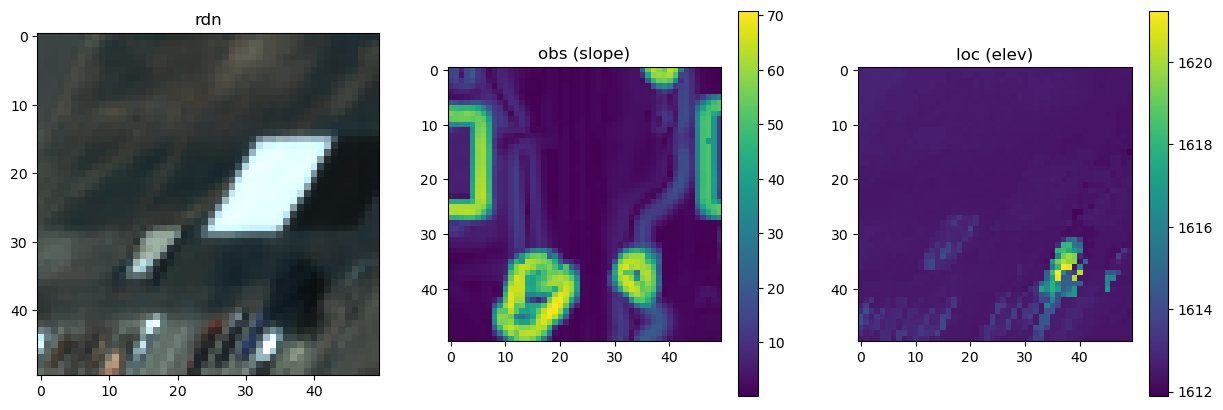

In [3]:
# cal tarp

# Tristan email: Calibration tarps are located at 480273E, 4431900N
x, y = 480273, 4431900

# Tristan shared four cal flightlines over the tarp, arbitrarily- choosing the first one
flight = 'NIS01_20180611_172310'

output_dir = out+'calTarp/subset/'
os.makedirs(output_dir, exist_ok=True)

subset_region(
    fp_rdn = cal+f'L1/{flight}_rdn.hdr',
    fp_obs = cal+f'L1/{flight}_rdn_obs_ort.hdr',
    fp_igm = cal+f'L1/{flight}_rdn_ort_igm.hdr',
    output_dir = output_dir,
    x = x,
    y = y,
    buf = buf,
    brighten_factor=1.5
)

In [4]:
# main flight area - aspen

# visually selected a point in the middle of a dense aspen stand
x, y = 324787.29, 4308930.18

# select a flight id
# ## figure out which flightlines contain the point + buffer area
# fps = glob(rmbl+'all_igm/*.hdr')
# ids = []
# for fp in fps:
#     igm = envi.open(fp).open_memmap(interleave='bip').copy()
#     xmin = np.nanmin(igm[...,0])
#     xmax = np.nanmax(igm[...,0])
#     ymin = np.nanmin(igm[...,1])
#     ymax = np.nanmax(igm[...,1])
#     if xmin<(x-buf) and xmax>(x+buf):
#         if ymin<(y-buf) and ymax>(y+buf):
#             ids.append(fp)
# print(f'flights containing roi: {len(ids)}')
# flight = ids[2].split('/')[-1].split('_rdn')[0] # above not actually working, debug later
# print(flight)
flight = 'NIS01_20180619_172934'

output_dir = out+'aspen/subset/'
os.makedirs(output_dir, exist_ok=True)

subset_region(
    fp_rdn = rmbl+f'all_radiance/{flight}_rdn.hdr',
    fp_obs = rmbl+f'all_obs/{flight}_rdn_obs.hdr',
    fp_igm = rmbl+f'all_igm/{flight}_rdn_ort_igm.hdr',
    output_dir = output_dir,
    x = x,
    y = y,
    buf = buf
)

# why is this so blue?

KeyboardInterrupt: 

/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/spectral/io/envi.py:175: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


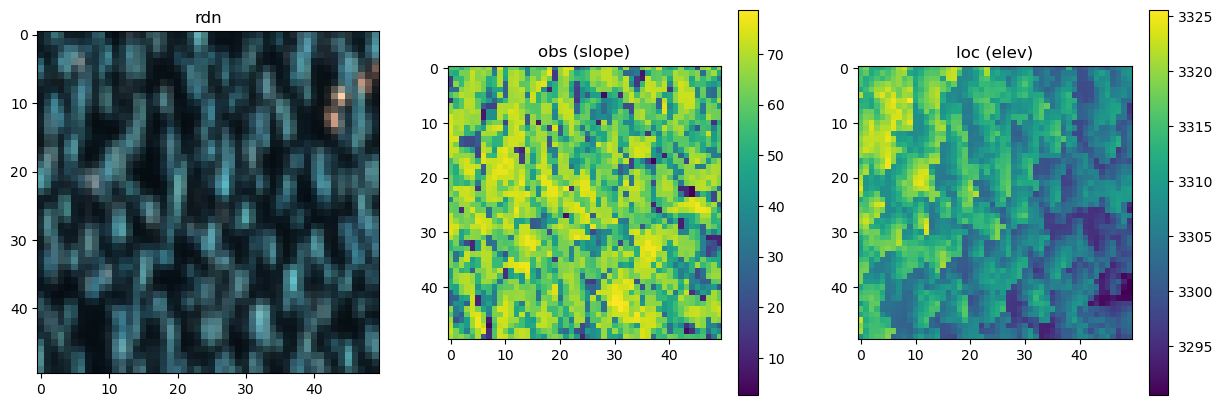

In [5]:
# main flight area - conifer

# visually selected a point in the middle of a dense conifer stand
x, y = 327125.78,4311428.84

# # select a flight id
# ## figure out which flightlines contain the point + buffer area
# fps = glob(rmbl+'*/*.hdr')
# ids = []
# for fp in fps:
#     igm = envi.open(fp).open_memmap(interleave='bip').copy()
#     xmin = np.nanmin(igm[...,0])
#     xmax = np.nanmax(igm[...,0])
#     ymin = np.nanmin(igm[...,1])
#     ymax = np.nanmax(igm[...,1])
#     if xmin<(x-buf) and xmax>(x+buf):
#         if ymin<(y-buf) and ymax>(y+buf):
#             ids.append(fp)
# print(f'flights containing roi: {len(ids)}')
# flight = ids[2].split('/')[-1].split('_rdn')[0] # above not actually working, debug later
# print(flight)
flight = 'NIS01_20180619_160339'

output_dir = out+'conifer/subset/'
os.makedirs(output_dir, exist_ok=True)

subset_region(
    fp_rdn = rmbl+f'all_radiance/{flight}_rdn.hdr',
    fp_obs = rmbl+f'all_obs/{flight}_rdn_obs.hdr',
    fp_igm = rmbl+f'all_igm/{flight}_rdn_ort_igm.hdr',
    output_dir = output_dir,
    x = x,
    y = y,
    buf = buf
)